# 02 · Cleaning & Normalization
Builds before/after windows, applies VADER sentiment, and pace-adjusts stats across eras.

Outputs: `data/processed/windows.csv` and `data/processed/normalized.csv`

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')


In [2]:
# Step 1: Score sentiment on lyric snippets
from src.sentiment import score_lyrics
df_sentiment = score_lyrics('../data/raw/mentions.csv')
print(df_sentiment[['player','artist','lyric','vader_compound']].head(10))


Saved sentiment scores to D:\Codes\hip-hoop\notebooks\..\data\processed\mentions_with_sentiment.csv

Sentiment summary:
count    160.000
mean       0.122
std        0.302
min       -0.747
25%        0.000
50%        0.000
75%        0.361
max        0.700
Name: vader_compound, dtype: float64

Mean by mention_type:
mention_type
compliment    0.123
diss          0.006
neutral       0.138
Name: vader_compound, dtype: float64
             player            artist  \
0      LeBron James             Drake   
1       Kobe Bryant         Lil Wayne   
2  Shaquille O'Neal  Notorious B.I.G.   
3     Allen Iverson             Jay-Z   
4      Kevin Durant    Kendrick Lamar   
5     Patrick Ewing  Notorious B.I.G.   
6    Michael Jordan             Jay-Z   
7       Gary Payton             Jay-Z   
8      Vince Carter          Ludacris   
9        Tim Duncan            Common   

                                               lyric  vader_compound  
0  That's why they call me Young Money LeBron Jam..

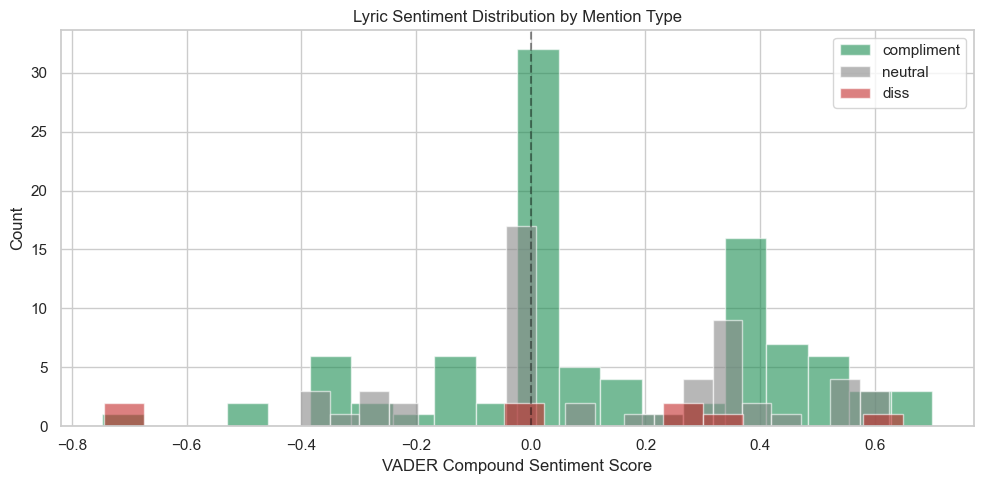

Note: sentiment scores don't always match manual labels — that's the point.


In [3]:
# Visualize sentiment distribution by mention type
fig, ax = plt.subplots(figsize=(10, 5))
for t, color in [('compliment','#1A8C50'), ('neutral','#888'), ('diss','#C42B2B')]:
    sub = df_sentiment[df_sentiment['mention_type'] == t]['vader_compound']
    ax.hist(sub, bins=20, alpha=0.6, label=t, color=color)
ax.axvline(0, color='black', linestyle='--', alpha=0.4)
ax.set_xlabel('VADER Compound Sentiment Score')
ax.set_ylabel('Count')
ax.set_title('Lyric Sentiment Distribution by Mention Type')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/sentiment_distribution.png', dpi=150)
plt.show()
print("Note: sentiment scores don't always match manual labels — that's the point.")


In [4]:
# Step 2: Build before/after windows from game logs
from src.build_windows import build_windows
df_windows = build_windows()
print(f"Windows shape: {df_windows.shape}")
print(df_windows[['player','mention_type','before_PTS_mean','after_30g_PTS_mean']].head(10))


  ⚠ No future games found for Michael Jordan after 2003-11-14
  ✗ No game log found for: Luka Doncic
  ✗ No game log found for: Nikola Jokic
  ✗ No game log found for: De'Aaron Fox
  ⚠ Insufficient data for Donovan Mitchell (off_season) around 2017-06-30
  ⚠ Insufficient data for Domantas Sabonis (off_season) around 2016-04-01
  ⚠ Insufficient data for Hassan Whiteside (in_season) around 2014-10-27
  ⚠ Insufficient data for Jimmy Butler (off_season) around 2011-07-12
  ⚠ Insufficient data for Pascal Siakam (off_season) around 2013-09-24
  ⚠ Insufficient data for Scottie Barnes (off_season) around 2021-09-03
  ⚠ Insufficient data for Cade Cunningham (off_season) around 2021-05-14
  ✗ No game log found for: Jalen Green
  ✗ No game log found for: Anthony Edwards
  ✗ No game log found for: LaMelo Ball
  ✗ No game log found for: Nikola Jokic
  ✗ No game log found for: Luka Doncic
  ⚠ Insufficient data for Anthony Davis (off_season) around 2012-07-31
  ⚠ No future games found for Zion Willia

In [5]:
# Check for missing data
missing = df_windows.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])
print(f"\nComplete rows: {df_windows.dropna(subset=['after_30g_PTS_mean']).shape[0]}")


Missing values per column:
after_1g_PTS_std    140
after_1g_AST_std    140
after_1g_REB_std    140
dtype: int64

Complete rows: 140


In [6]:
# Step 3: Pace-adjust and compute deltas
from src.normalize import normalize
df_norm = normalize()
print("\nDelta columns created:")
delta_cols = [c for c in df_norm.columns if c.startswith('delta_')]
print(delta_cols)


Normalized data saved to D:\Codes\hip-hoop\notebooks\..\data\processed\normalized.csv
Shape: (140, 93)

Delta columns created:
['delta_after_1g_PTS', 'delta_after_1g_PTS_adj', 'delta_after_1g_AST', 'delta_after_1g_AST_adj', 'delta_after_1g_REB', 'delta_after_1g_REB_adj', 'delta_after_10g_PTS', 'delta_after_10g_PTS_adj', 'delta_after_10g_AST', 'delta_after_10g_AST_adj', 'delta_after_10g_REB', 'delta_after_10g_REB_adj', 'delta_after_30g_PTS', 'delta_after_30g_PTS_adj', 'delta_after_30g_AST', 'delta_after_30g_AST_adj', 'delta_after_30g_REB', 'delta_after_30g_REB_adj', 'delta_after_season_PTS', 'delta_after_season_PTS_adj', 'delta_after_season_AST', 'delta_after_season_AST_adj', 'delta_after_season_REB', 'delta_after_season_REB_adj']


In [7]:
# Preview key delta stats
print(df_norm[['player','mention_type','delta_after_30g_PTS_adj',
               'delta_after_30g_AST_adj','delta_after_30g_REB_adj',
               'composite_delta_30g']].dropna().head(15))


              player mention_type  delta_after_30g_PTS_adj  \
0       LeBron James   compliment                     0.57   
1        Kobe Bryant   compliment                     2.94   
2   Shaquille O'Neal   compliment                     0.00   
3      Allen Iverson   compliment                     1.94   
4       Kevin Durant      neutral                     0.44   
5      Patrick Ewing         diss                    -3.23   
6        Gary Payton      neutral                     2.05   
7       Vince Carter   compliment                     1.15   
8         Tim Duncan   compliment                     2.52   
9        Dwyane Wade   compliment                    -2.22   
10        Chris Paul   compliment                    -1.20   
11     Kevin Garnett   compliment                    -0.18   
12      James Harden   compliment                    -3.50   
13     Stephen Curry   compliment                    -0.83   
14      Kyrie Irving      neutral                     2.24   

    del

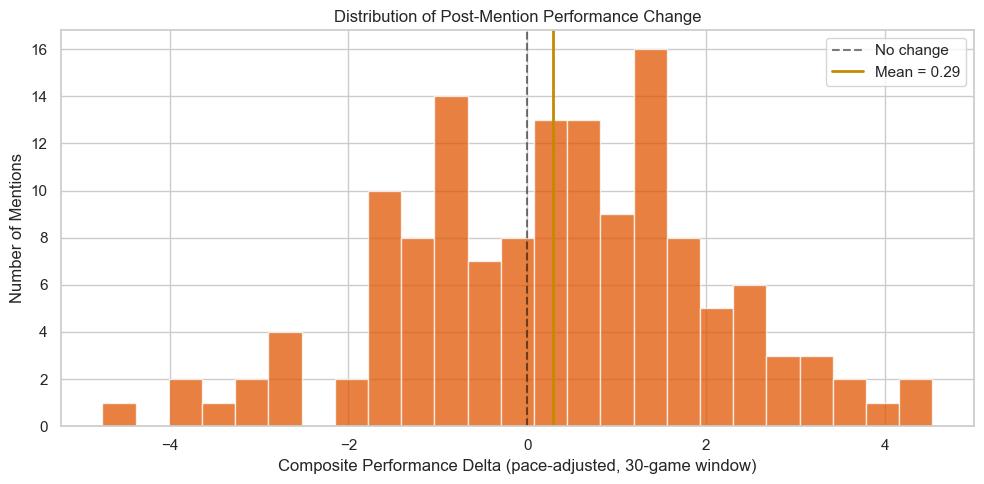

In [8]:
# Distribution of composite deltas
fig, ax = plt.subplots(figsize=(10, 5))
df_plot = df_norm.dropna(subset=['composite_delta_30g'])
ax.hist(df_plot['composite_delta_30g'], bins=25, color='#E05500', alpha=0.75, edgecolor='white')
ax.axvline(0, color='black', linestyle='--', alpha=0.5, label='No change')
ax.axvline(df_plot['composite_delta_30g'].mean(), color='#C48A00', linestyle='-',
           linewidth=2, label=f"Mean = {df_plot['composite_delta_30g'].mean():.2f}")
ax.set_xlabel('Composite Performance Delta (pace-adjusted, 30-game window)')
ax.set_ylabel('Number of Mentions')
ax.set_title('Distribution of Post-Mention Performance Change')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/delta_distribution.png', dpi=150)
plt.show()
